EDA and Preprocessing

EDA

Dataset contains no missing values and a balanced target variable.

Numeric features (age, bmi, HbA1c_level, blood_glucose_level) were analyzed using distributions and correlation heatmap.

Outliers were identified in BMI and blood glucose levels using boxplots.

HbA1c and blood glucose showed strong relevance to diabetes.

Preprocessing

Duplicate rows were removed.

Binary variables (hypertension, heart_disease, diabetes) were converted to categorical.

Outliers in numeric features were handled using the IQR capping method.

Categorical features (gender, smoking_history) were marked for one-hot encoding.

Feature scaling was planned for numeric variables after train–test split.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

# Check dataset shape and preview
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (183000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,44.0,0,0,never,23.51,5.7,155,1
1,Female,44.0,0,0,never,37.20,5.7,145,0
2,Male,80.0,1,0,former,27.32,4.0,100,0
3,Male,64.0,0,0,former,26.97,5.7,200,1
4,Male,19.0,0,0,never,37.54,4.5,160,0


In [2]:
# Check column names, data types, and non-null counts
df.info()

# Statistical summary of numerical features
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183000 entries, 0 to 182999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               183000 non-null  object 
 1   age                  183000 non-null  float64
 2   hypertension         183000 non-null  int64  
 3   heart_disease        183000 non-null  int64  
 4   smoking_history      183000 non-null  object 
 5   bmi                  183000 non-null  float64
 6   HbA1c_level          183000 non-null  float64
 7   blood_glucose_level  183000 non-null  int64  
 8   diabetes             183000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 12.6+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,183000.000000,183000.00000,183000.000000,183000.000000,183000.000000,183000.000000,183000.000000
mean,50.506746,0.15423,0.089432,29.457722,6.165816,163.504874,0.500000
std,21.522080,0.36117,0.285367,7.466507,1.280889,56.964845,0.500001
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,36.000000,0.00000,0.000000,25.790000,5.700000,130.000000,0.000000
50%,54.000000,0.00000,0.000000,27.320000,6.100000,155.000000,0.500000
75%,67.000000,0.00000,0.000000,32.870000,6.600000,200.000000,1.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [3]:
# Check missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Confirm if any missing values exist in the dataset
has_missing = df.isnull().values.any()
print("Any missing values in dataset:", has_missing)



Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
Any missing values in dataset: False


In [4]:
#  shape and duplicates BEFORE
print("Before drop_duplicates shape:", df.shape)
print("Before drop_duplicates duplicates:", df.duplicated().sum())

# Drop duplicates (update df)
df = df.drop_duplicates()

# shape and duplicates AFTER
print("After drop_duplicates shape:", df.shape)
print("After drop_duplicates duplicates:", df.duplicated().sum())


Before drop_duplicates shape: (183000, 9)
Before drop_duplicates duplicates: 86854
After drop_duplicates shape: (96146, 9)
After drop_duplicates duplicates: 0


In [5]:
# Convert binary columns to categorical type
binary_cols = ["hypertension", "heart_disease", "diabetes"]
df[binary_cols] = df[binary_cols].astype("category")

# Verify data types
df.dtypes


,0
gender,object
age,float64
hypertension,category
heart_disease,category
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,category


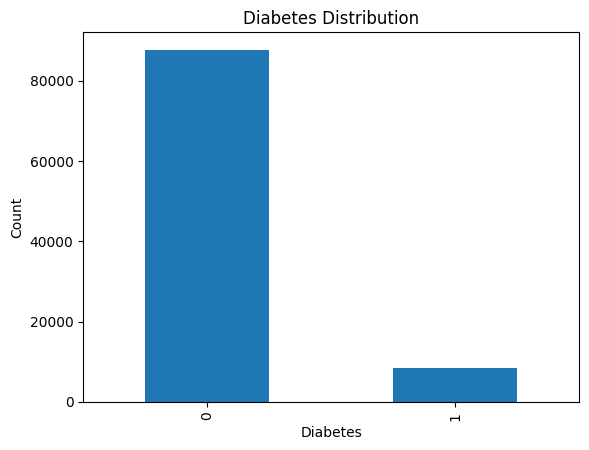

/tmp/ipython-input-4034554884.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("diabetes")[numeric_cols].mean()


,age,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,
0,39.943229,26.869003,5.396936,132.818489
1,60.925961,31.997755,6.934827,194.026173


In [6]:
# Target variable distribution
df["diabetes"].value_counts()

# Plot target distribution
df["diabetes"].value_counts().plot(kind="bar")
plt.title("Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

# Mean comparison of numeric features by diabetes
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
df.groupby("diabetes")[numeric_cols].mean()


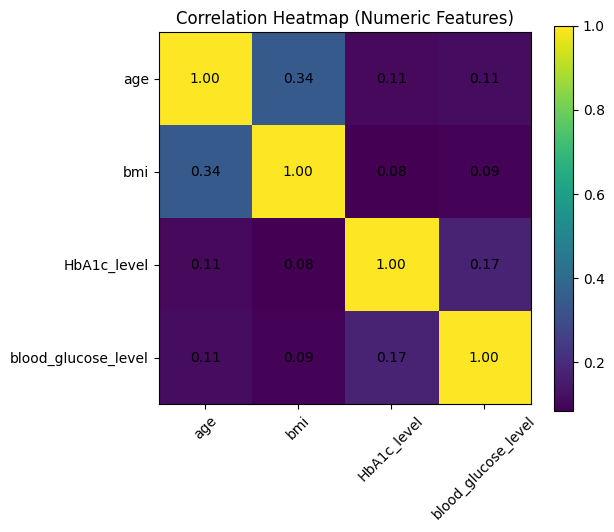

In [7]:
# Correlation heatmap with visible values
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (Numeric Features)")

# Add correlation values inside cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.show()



/tmp/ipython-input-2937303516.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols)


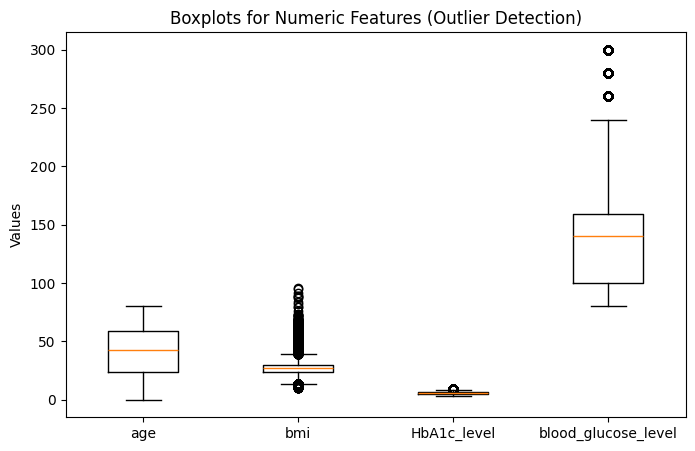

In [8]:
# Boxplots for numeric columns to detect outliers (single plot)
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

plt.figure(figsize=(8, 5))
plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols)
plt.title("Boxplots for Numeric Features (Outlier Detection)")
plt.ylabel("Values")
plt.show()


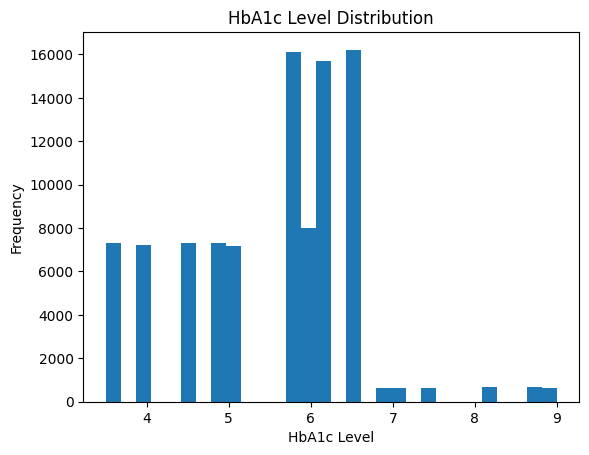

In [9]:
# Distribution of HbA1c level
plt.hist(df["HbA1c_level"], bins=30)
plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")
plt.show()


In [10]:
# Apply IQR method to handle outliers in numeric columns
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[col] = df[col].clip(lower_bound, upper_bound)

print("Outliers handled using IQR capping method.")


Outliers handled using IQR capping method.


In [11]:
# Separate features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]


In [12]:
# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=["gender", "smoking_history"],
    drop_first=True
)

X.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,44.0,0,0,23.51,5.7,155.0,False,False,False,False,False,True,False
1,44.0,0,0,37.20,5.7,145.0,False,False,False,False,False,True,False
2,80.0,1,0,27.32,4.0,100.0,True,False,False,False,True,False,False
3,64.0,0,0,26.97,5.7,200.0,True,False,False,False,True,False,False
4,19.0,0,0,37.54,4.5,160.0,True,False,False,False,False,True,False


In [13]:
from sklearn.model_selection import train_test_split

# Ensure X and y are created from the UPDATED dataframe
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes to verify split
print("Full dataset shape:", df.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Full dataset shape: (96146, 9)
Training set shape: (76916, 8)
Test set shape: (19230, 8)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
cat_cols = ["gender", "smoking_history", "hypertension", "heart_disease"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)


In [16]:
from imblearn.over_sampling import SMOTE

# Transform to numeric arrays
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_p, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())
print("X_train_smote shape:", X_train_smote.shape)
print("X_test_p shape:", X_test_p.shape)



Before SMOTE:
 diabetes
0    70130
1     6786
Name: count, dtype: int64
After SMOTE:
 diabetes
0    70130
1    70130
Name: count, dtype: int64
X_train_smote shape: (140260, 17)
X_test_p shape: (19230, 17)


In [17]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test_p)
y_prob_rf = rf_model.predict_proba(X_test_p)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9555902236089444
Random Forest ROC-AUC: 0.9649875659365846

Confusion Matrix:
 [[17121   413]
 [  441  1255]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98     17534
           1       0.75      0.74      0.75      1696

    accuracy                           0.96     19230
   macro avg       0.86      0.86      0.86     19230
weighted avg       0.96      0.96      0.96     19230



In [18]:
# Histogram-based Gradient Boosting Classifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
hgb_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# Train model
hgb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_hgb = hgb_model.predict(X_test_p)

# Evaluation
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_hgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hgb))


Gradient Boosting Accuracy: 0.9662506500260011

Confusion Matrix:
 [[17342   192]
 [  457  1239]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.87      0.73      0.79      1696

    accuracy                           0.97     19230
   macro avg       0.92      0.86      0.89     19230
weighted avg       0.96      0.97      0.96     19230



In [19]:
# Support Vector Machine (RBF Kernel)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Initialize model
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Train model
svm_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_svm = svm_model.predict(X_test_p)
y_prob_svm = svm_model.predict_proba(X_test_p)[:, 1]

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8895475819032761
SVM ROC-AUC: 0.9698410070138664

Confusion Matrix:
 [[15563  1971]
 [  153  1543]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94     17534
           1       0.44      0.91      0.59      1696

    accuracy                           0.89     19230
   macro avg       0.71      0.90      0.76     19230
weighted avg       0.94      0.89      0.91     19230

